In [2]:
# Import libraries

import warnings
warnings.filterwarnings("ignore")

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    mannwhitneyu,
    kruskal,
    chi2_contingency,
    spearmanr
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap

In [3]:
# Plotting settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [4]:
# Load Dataset

FILE_PATH = "data.csv"

df_raw = pd.read_csv(FILE_PATH)

print("Original dataset shape:")
print(df_raw.shape)

Original dataset shape:
(418, 16)


In [5]:
print("Column names:")
print(df_raw.columns.tolist())

Column names:
['organisation', 'alternative name', 'records lost', 'year   ', 'date', 'story', 'sector', 'method', 'interesting story', 'data sensitivity', 'displayed records', 'Unnamed: 11', 'source name', '1st source link', '2nd source link', 'ID']


In [6]:
print("First 5 rows:")
display(df_raw.head())

First 5 rows:


,organisation,alternative name,records lost,year,date,story,sector,method,interesting story,data sensitivity,displayed records,Unnamed: 11,source name,1st source link,2nd source link,ID
0,visualisation here: https://informationisbeaut...,NaN,"(use 3m, 4m, 5m or 10m to approximate unknown ...",year story broke,NaN,NaN,web\nhealthcare\napp\nretail\ngaming\ntranspor...,poor security\nhacked\noops!\nlost device \nin...,NaN,1. Just email address/Online information \n2 S...,"=IF(C3>100000000,C3,"")",NaN,NaN,NaN,NaN,NaN
1,Plex,NaN,"15,000,000",2022,Aug 2022,"Intruders access password data, usernames, and...",web,hacked,NaN,1,NaN,NaN,Ars technica,https://arstechnica.com/information-technology...,NaN,418.000
2,Twitter,NaN,"5,400,000",2021,Dec 2021,Zero day vulnerability allowed a threat actor ...,web,hacked,NaN,2,NaN,NaN,Bleeping Computer,https://www.bleepingcomputer.com/news/security...,NaN,419.000
3,Shanghai Police,NaN,"500,000,000",2022,Jul 2022,A database containing records of over a billio...,financial,hacked,NaN,5,"""one billion""",NaN,The Register,https://www.theregister.com/2022/07/05/shangha...,NaN,420.000
4,"City of Amagasaki, Japan",NaN,"500,000",2022,Jun 2022,An unnamed government official lost his bag af...,government,oops!,NaN,3,NaN,NaN,BBC,https://www.bbc.co.uk/news/world-asia-61921222,NaN,421.000


In [7]:
# Initial Dataset Inspection

print("Dataset dimensions:")
print(f"Rows    : {df_raw.shape[0]}")
print(f"Columns : {df_raw.shape[1]}")

Dataset dimensions:
Rows    : 418
Columns : 16


In [8]:
print("Data types:")
display(df_raw.dtypes)

Data types:


,0
organisation,object
alternative name,object
records lost,object
year,object
date,object
story,object
sector,object
method,object
interesting story,object
data sensitivity,object


In [9]:
print("Missing values:")
missing_summary = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percentage": df_raw.isna().mean() * 100
})

display(
    missing_summary
    .sort_values("Missing_Percentage", ascending=False)
)

Missing values:


,Missing_Count,Missing_Percentage
Unnamed: 11,418,100.000
2nd source link,386,92.344
displayed records,343,82.057
interesting story,333,79.665
alternative name,274,65.550
story,7,1.675
1st source link,2,0.478
date,1,0.239
source name,1,0.239
data sensitivity,1,0.239


In [10]:
print("Duplicate rows:")
print(df_raw.duplicated().sum())

Duplicate rows:
0


In [11]:
# Remove Embedded Description Row

original_rows = len(df_raw)

df = df_raw.iloc[1:].copy()

rows_after_header_removal = len(df)

print("Rows before removing description row:", original_rows)
print("Rows after removing description row :", rows_after_header_removal)
print("Rows removed                         :", original_rows - rows_after_header_removal)

Rows before removing description row: 418
Rows after removing description row : 417
Rows removed                         : 1


In [12]:
# Clean Coloumn Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print(df.columns.tolist())

['organisation', 'alternative_name', 'records_lost', 'year', 'date', 'story', 'sector', 'method', 'interesting_story', 'data_sensitivity', 'displayed_records', 'unnamed:_11', 'source_name', '1st_source_link', '2nd_source_link', 'id']


In [13]:
# Remove completely empty columns

empty_columns = [
    col for col in df.columns
    if df[col].isna().all()
]


print("Completely empty columns:")
print(empty_columns)

df = df.drop(columns=empty_columns)

print("\nDataset shape after removing empty columns:")
print(df.shape)

Completely empty columns:
['unnamed:_11']

Dataset shape after removing empty columns:
(417, 15)


In [14]:
# Clean Records Lost

def clean_records_lost(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()

    # Remove commas and spaces
    value = value.replace(",", "")
    value = value.replace(" ", "")

    # Remove approximate symbols
    value = value.replace("~", "")
    value = value.replace("approximately", "")
    value = value.replace("approx", "")

    match = re.match(
        r"^([0-9]*\.?[0-9]+)(m|million|b|billion|k|thousand)?$",
        value
    )

    if match:
        number = float(match.group(1))
        unit = match.group(2)

        if unit in ["m", "million"]:
            number *= 1_000_000

        elif unit in ["b", "billion"]:
            number *= 1_000_000_000

        elif unit in ["k", "thousand"]:
            number *= 1_000

        return number

    # Otherwise attempt direct numeric conversion
    try:
        return float(value)
    except:
        return np.nan


df["records_lost"] = df["records_lost"].apply(clean_records_lost)
print(df["records_lost"].describe())

count           417.000
mean     34,387,245.110
std      92,755,829.678
min              30.000
25%         500,000.000
50%       3,100,000.000
75%      18,218,203.000
max     700,000,000.000
Name: records_lost, dtype: float64


In [15]:
# Clean Year

df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

df["year"] = df["year"].astype("Int64")

print("Year range:")
print(df["year"].min(), "-", df["year"].max())

print("\nMissing years:")
print(df["year"].isna().sum())

print("\nYear distribution:")
display(
    df["year"]
    .value_counts()
    .sort_index()
)

Year range:
2004 - 2022

Missing years:
0

Year distribution:


,count
year,
2004,1
2005,3
2006,5
2007,10
2008,19
2009,9
2010,13
2011,37
2012,23


In [16]:
# Clean Sector

df["sector"] = (
    df["sector"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Standardise known equivalent labels
sector_mapping = {
    "financial": "finance"
}

df["sector"] = df["sector"].replace(sector_mapping)

print("Unique sectors:")
display(
    df["sector"]
    .value_counts()
)

Unique sectors:


,count
sector,
web,111
finance,44
government,44
health,43
retail,37
telecoms,22
app,21
tech,20
transport,17


In [17]:
# Clean Breach Method

df["method"] = (
    df["method"]
    .astype("string")
    .str.strip()
    .str.lower()
)

print("Breach methods:")
display(
    df["method"]
    .value_counts()
)

Breach methods:


,count
method,
hacked,274
poor security,53
lost device,48
oops!,22
inside job,20


In [19]:
# Clean data sensitivity

df["data_sensitivity"] = pd.to_numeric(
    df["data_sensitivity"],
    errors="coerce"
)
print(df["data_sensitivity"].value_counts(dropna=False).sort_index())

data_sensitivity
1.000    128
2.000    134
3.000     66
4.000     61
5.000     27
NaN        1
Name: count, dtype: int64


In [20]:
# Remove duplicate observations

duplicates_before = df.duplicated().sum()

print("Duplicate rows:", duplicates_before)

if duplicates_before > 0:
    df = df.drop_duplicates().copy()

print("Dataset shape after duplicate removal:")
print(df.shape)

Duplicate rows: 0
Dataset shape after duplicate removal:
(417, 15)


In [21]:
# Missing data analysis

missing_table = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    )
})

missing_table = missing_table.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing_table)

,Variable,Missing_Count,Missing_Percentage
13,2nd_source_link,385,92.326
10,displayed_records,343,82.254
8,interesting_story,332,79.616
1,alternative_name,273,65.468
5,story,6,1.439
9,data_sensitivity,1,0.240
12,1st_source_link,1,0.240
6,sector,0,0.000
4,date,0,0.000
3,year,0,0.000


In [22]:
# Final Analytical Dataset

analysis_columns = [
    "organisation",
    "records_lost",
    "year",
    "sector",
    "method",
    "data_sensitivity"
]

analysis_df = df[analysis_columns].copy()

print("Before removing missing analytical values:")
print(analysis_df.shape)

# Required variables for main analysis
analysis_df = analysis_df.dropna(
    subset=[
        "records_lost",
        "year",
        "sector",
        "method"
    ]
).copy()

print("\nFinal analytical dataset:")
print(analysis_df.shape)
display(analysis_df.head())

Before removing missing analytical values:
(417, 6)

Final analytical dataset:
(417, 6)


,organisation,records_lost,year,sector,method,data_sensitivity
1,Plex,"15,000,000.000",2022,web,hacked,1.000
2,Twitter,"5,400,000.000",2021,web,hacked,2.000
3,Shanghai Police,"500,000,000.000",2022,finance,hacked,5.000
4,"City of Amagasaki, Japan","500,000.000",2022,government,oops!,3.000
5,Dubai Real Estate Leak,"800,000.000",2022,finance,inside job,1.000


In [23]:
# Regulatory Period Classification

analysis_df["gdpr_period"] = np.where(
    analysis_df["year"] < 2018,
    "Pre-GDPR",
    "Post-GDPR"
)

analysis_df["ccpa_period"] = np.where(
    analysis_df["year"] < 2020,
    "Pre-CCPA",
    "Post-CCPA"
)

# Binary versions for modelling
analysis_df["gdpr_post"] = (
    analysis_df["year"] >= 2018
).astype(int)

analysis_df["ccpa_post"] = (
    analysis_df["year"] >= 2020
).astype(int)

display(
    analysis_df[
        [
            "year",
            "gdpr_period",
            "ccpa_period",
            "gdpr_post",
            "ccpa_post"
        ]
    ].head(20)
)

,year,gdpr_period,ccpa_period,gdpr_post,ccpa_post
1,2022,Post-GDPR,Post-CCPA,1,1
2,2021,Post-GDPR,Post-CCPA,1,1
3,2022,Post-GDPR,Post-CCPA,1,1
4,2022,Post-GDPR,Post-CCPA,1,1
5,2022,Post-GDPR,Post-CCPA,1,1
6,2022,Post-GDPR,Post-CCPA,1,1
7,2022,Post-GDPR,Post-CCPA,1,1
8,2022,Post-GDPR,Post-CCPA,1,1
9,2022,Post-GDPR,Post-CCPA,1,1
10,2022,Post-GDPR,Post-CCPA,1,1


In [24]:
# Create log-transformed severity

analysis_df["log_records_lost"] = np.log1p(
    analysis_df["records_lost"]
)

analysis_df[
    [
        "records_lost",
        "log_records_lost"
    ]
].describe()

,records_lost,log_records_lost
count,417.000,417.000
mean,"34,387,245.110",14.935
std,"92,755,829.678",2.511
min,30.000,3.434
25%,"500,000.000",13.122
50%,"3,100,000.000",14.947
75%,"18,218,203.000",16.718
max,"700,000,000.000",20.367


In [25]:
# Exploratory High-Severity Threshold

overall_q75 = analysis_df["records_lost"].quantile(0.75)

print(
    f"Overall 75th percentile: "
    f"{overall_q75:,.0f} records"
)

analysis_df["high_severity_exploratory"] = (
    analysis_df["records_lost"] >= overall_q75
).astype(int)

print("\nExploratory class distribution:")
display(
    analysis_df["high_severity_exploratory"]
    .value_counts()
    .rename({
        0: "Normal severity",
        1: "High severity"
    })
)

Overall 75th percentile: 18,218,203 records

Exploratory class distribution:


,count
high_severity_exploratory,
Normal severity,312
High severity,105


In [26]:
# Cleaning summary table

cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original CSV",
        "Remove embedded description row",
        "Remove completely empty columns",
        "Remove duplicate rows",
        "Final analytical dataset"
    ],
    "Records": [
        len(df_raw),
        len(df_raw) - 1,
        len(df_raw) - 1,
        len(df_raw) - 1 - duplicates_before,
        len(analysis_df)
    ]
})

display(cleaning_summary)

,Stage,Records
0,Original CSV,418
1,Remove embedded description row,417
2,Remove completely empty columns,417
3,Remove duplicate rows,417
4,Final analytical dataset,417


In [27]:
# Descriptive Statistics

severity_descriptive = pd.DataFrame({
    "Statistic": [
        "Number of observations",
        "Mean",
        "Standard deviation",
        "Minimum",
        "25th percentile",
        "Median",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum"
    ],
    "Records lost": [
        analysis_df["records_lost"].count(),
        analysis_df["records_lost"].mean(),
        analysis_df["records_lost"].std(),
        analysis_df["records_lost"].min(),
        analysis_df["records_lost"].quantile(0.25),
        analysis_df["records_lost"].median(),
        analysis_df["records_lost"].quantile(0.75),
        analysis_df["records_lost"].quantile(0.90),
        analysis_df["records_lost"].quantile(0.95),
        analysis_df["records_lost"].quantile(0.99),
        analysis_df["records_lost"].max()
    ]
})

display(severity_descriptive)

,Statistic,Records lost
0,Number of observations,417.000
1,Mean,"34,387,245.110"
2,Standard deviation,"92,755,829.678"
3,Minimum,30.000
4,25th percentile,"500,000.000"
5,Median,"3,100,000.000"
6,75th percentile,"18,218,203.000"
7,90th percentile,"82,080,000.000"
8,95th percentile,"176,400,000.000"
9,99th percentile,"516,800,000.000"


In [28]:
# Annual breach frequency

annual_breaches = (
    analysis_df
    .groupby("year")
    .size()
    .reset_index(name="breach_count")
)

display(annual_breaches)

,year,breach_count
0,2004,1
1,2005,3
2,2006,5
3,2007,10
4,2008,19
5,2009,9
6,2010,13
7,2011,37
8,2012,23
9,2013,35


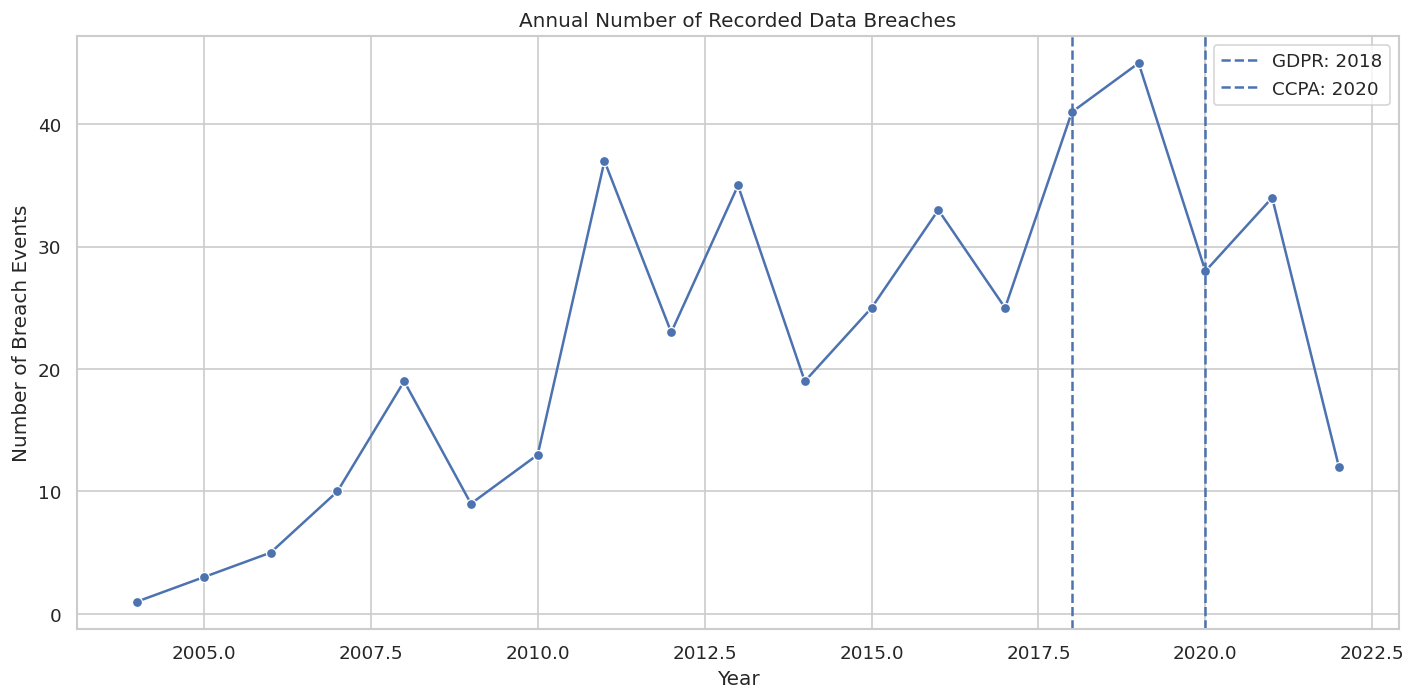

In [29]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=annual_breaches,
    x="year",
    y="breach_count",
    marker="o"
)

plt.axvline(
    x=2018,
    linestyle="--",
    label="GDPR: 2018"
)

plt.axvline(
    x=2020,
    linestyle="--",
    label="CCPA: 2020"
)

plt.title("Annual Number of Recorded Data Breaches")
plt.xlabel("Year")
plt.ylabel("Number of Breach Events")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Annual severity

annual_severity = (
    analysis_df
    .groupby("year")
    .agg(
        breach_count=("records_lost", "count"),
        total_records_lost=("records_lost", "sum"),
        mean_records_lost=("records_lost", "mean"),
        median_records_lost=("records_lost", "median")
    )
    .reset_index()
)

display(annual_severity)

,year,breach_count,total_records_lost,mean_records_lost,median_records_lost
0,2004,1,"92,000,000.000","92,000,000.000","92,000,000.000"
1,2005,3,"44,100,000.000","14,700,000.000","3,900,000.000"
2,2006,5,"50,825,000.000","10,165,000.000","4,000,000.000"
3,2007,10,"150,597,405.000","15,059,740.500","4,650,000.000"
4,2008,19,"76,255,500.000","4,013,447.368","2,100,000.000"
5,2009,9,"245,895,400.000","27,321,711.111","1,500,000.000"
6,2010,13,"9,783,285.000","752,560.385","398,000.000"
7,2011,37,"201,236,162.000","5,438,815.189","935,000.000"
8,2012,23,"221,926,177.000","9,648,964.217","3,600,000.000"
9,2013,35,"1,272,018,579.000","36,343,387.971","1,500,000.000"


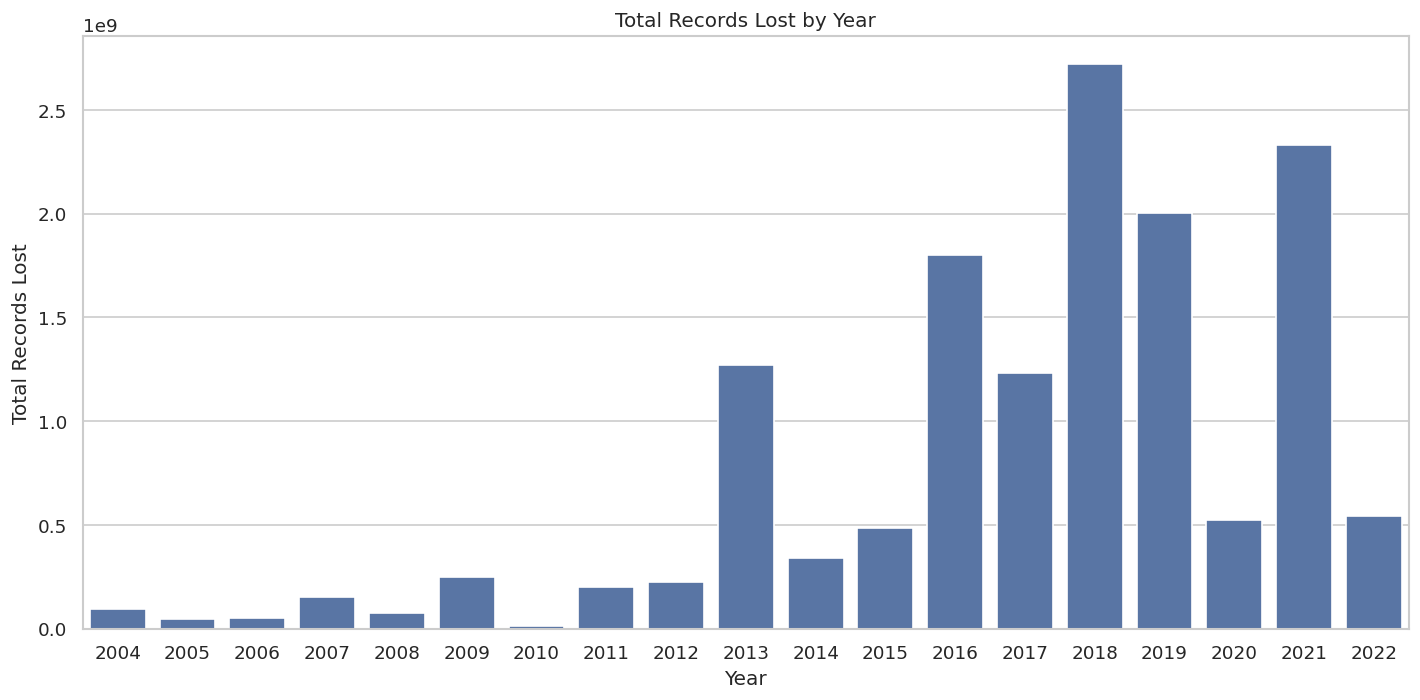

In [32]:
# Total records lost by year

plt.figure(figsize=(12, 6))

sns.barplot(
    data=annual_severity,
    x="year",
    y="total_records_lost"
)

plt.title("Total Records Lost by Year")
plt.xlabel("Year")
plt.ylabel("Total Records Lost")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

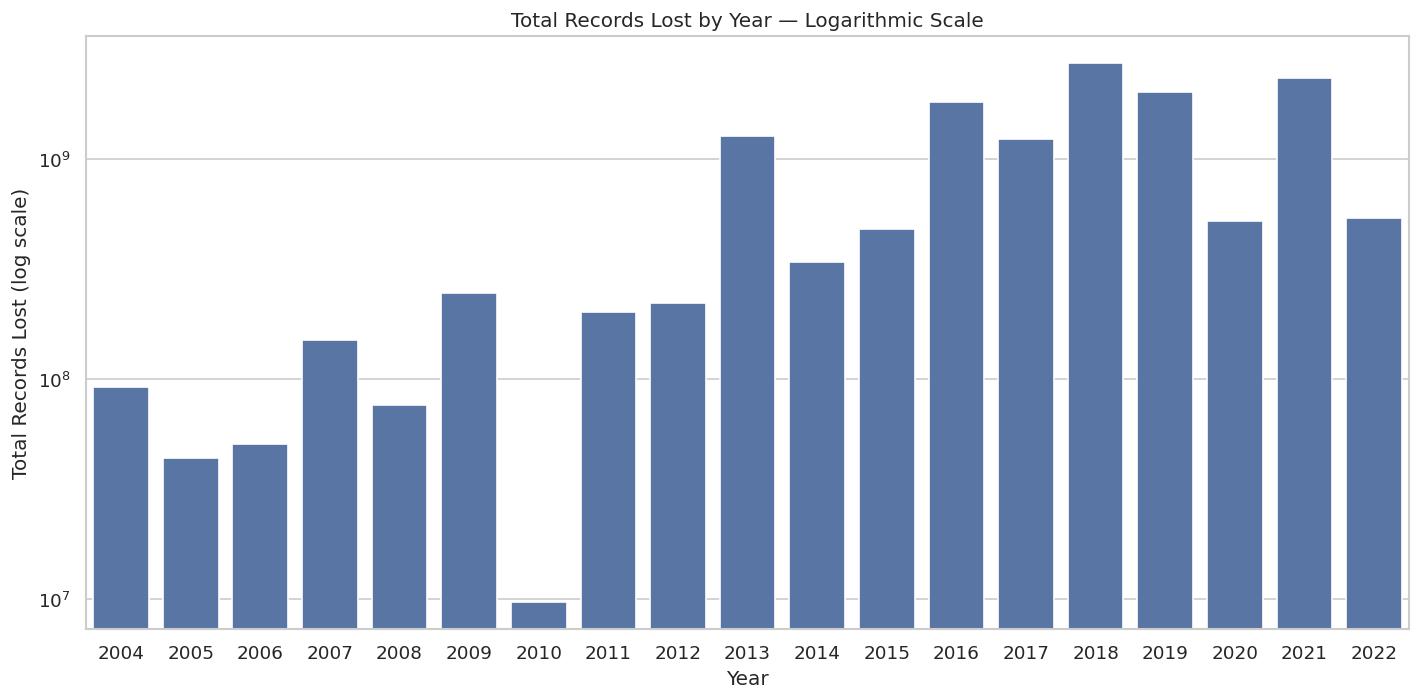

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=annual_severity,
    x="year",
    y="total_records_lost"
)

plt.yscale("log")

plt.title("Total Records Lost by Year — Logarithmic Scale")
plt.xlabel("Year")
plt.ylabel("Total Records Lost (log scale)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

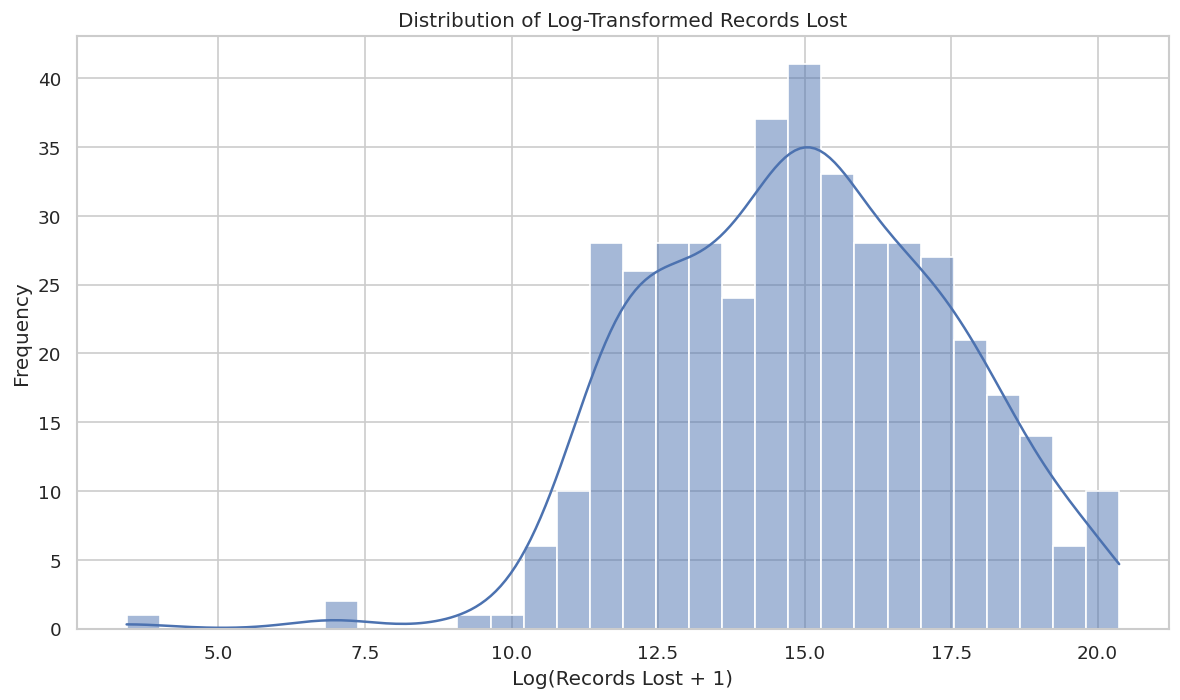

In [35]:
# Distribution of breach severity

plt.figure(figsize=(10, 6))

sns.histplot(
    data=analysis_df,
    x="log_records_lost",
    bins=30,
    kde=True
)

plt.title("Distribution of Log-Transformed Records Lost")
plt.xlabel("Log(Records Lost + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

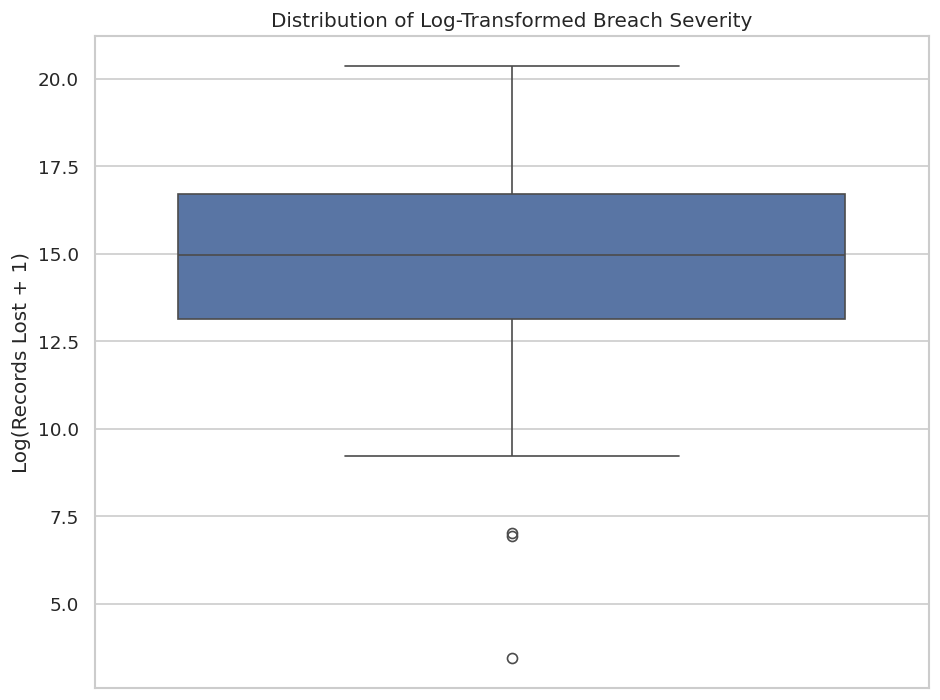

In [36]:
# Severity boxplot

plt.figure(figsize=(8, 6))

sns.boxplot(
    y=analysis_df["log_records_lost"]
)

plt.title("Distribution of Log-Transformed Breach Severity")
plt.ylabel("Log(Records Lost + 1)")

plt.tight_layout()
plt.show()

In [37]:
# Sector frequency

sector_frequency = (
    analysis_df["sector"]
    .value_counts()
    .reset_index()
)

sector_frequency.columns = [
    "sector",
    "breach_count"
]

sector_frequency["percentage"] = (
    sector_frequency["breach_count"]
    / sector_frequency["breach_count"].sum()
    * 100
)

display(sector_frequency)

,sector,breach_count,percentage
0,web,111,26.619
1,finance,44,10.552
2,government,44,10.552
3,health,43,10.312
4,retail,37,8.873
5,telecoms,22,5.276
6,app,21,5.036
7,tech,20,4.796
8,transport,17,4.077
9,gaming,16,3.837


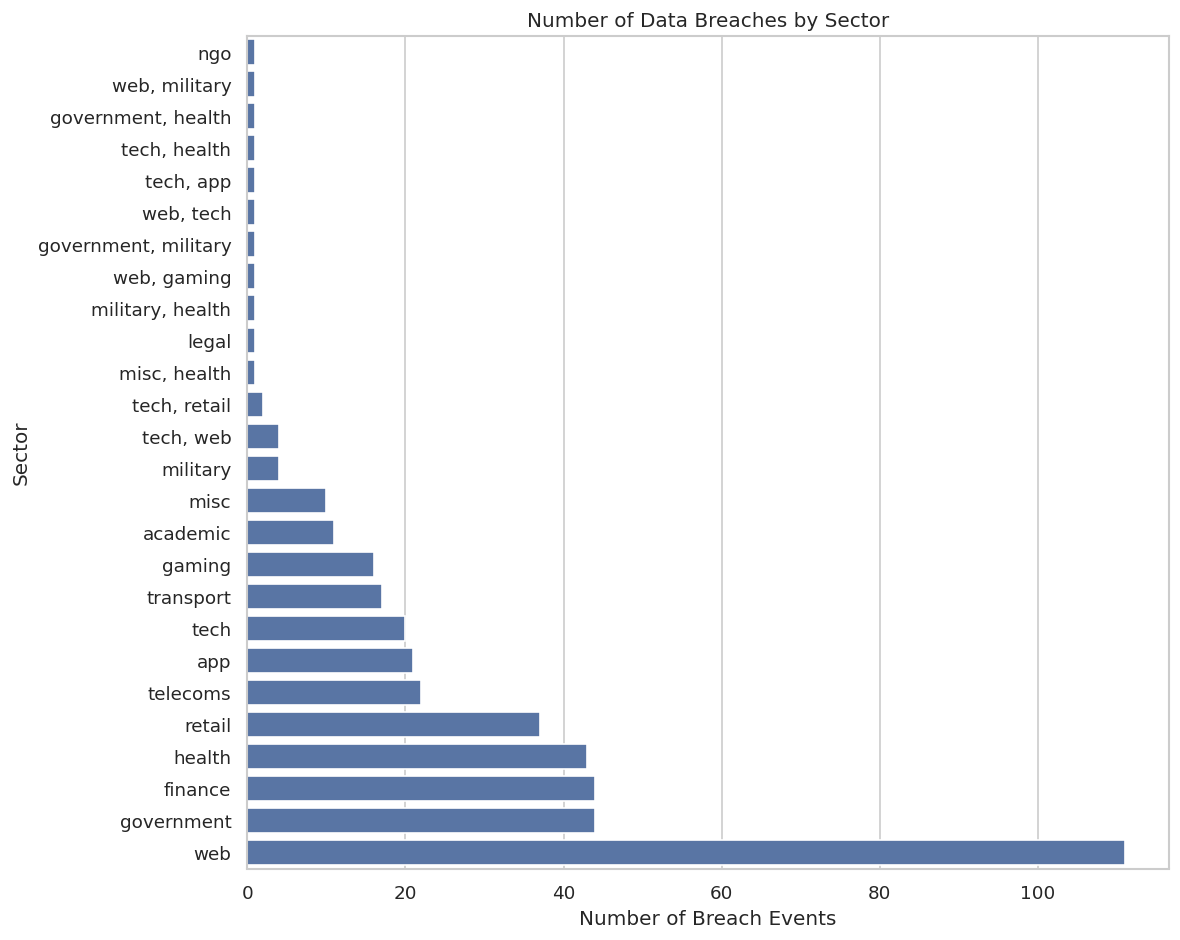

In [38]:
# Sector frequency plot

sector_plot = (
    sector_frequency
    .sort_values("breach_count", ascending=True)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=sector_plot,
    x="breach_count",
    y="sector"
)

plt.title("Number of Data Breaches by Sector")
plt.xlabel("Number of Breach Events")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [39]:
# Sector severity

sector_summary = (
    analysis_df
    .groupby("sector")
    .agg(
        breach_count=("records_lost", "count"),
        total_records_lost=("records_lost", "sum"),
        mean_records_lost=("records_lost", "mean"),
        median_records_lost=("records_lost", "median"),
        q1_records_lost=("records_lost", lambda x: x.quantile(0.25)),
        q3_records_lost=("records_lost", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

sector_summary["percentage"] = (
    sector_summary["breach_count"]
    / len(analysis_df)
    * 100
)

sector_summary = sector_summary.sort_values(
    "breach_count",
    ascending=False
)

display(sector_summary)

,sector,breach_count,total_records_lost,mean_records_lost,median_records_lost,q1_records_lost,q3_records_lost,percentage
22,web,111,"7,022,471,873.000","63,265,512.369","14,800,000.000","1,900,000.000","49,000,000.000",26.619
4,government,44,"896,299,573.000","20,370,444.841","2,350,000.000","202,500.000","6,125,000.000",10.552
2,finance,44,"1,669,564,286.000","37,944,642.864","2,650,000.000","375,000.000","9,875,000.000",10.552
7,health,43,"174,669,929.000","4,062,091.372","800,000.000","204,055.500","2,850,000.000",10.312
14,retail,37,"900,973,933.000","24,350,646.838","4,200,000.000","600,000.000","18,218,203.000",8.873
20,telecoms,22,"873,584,000.000","39,708,363.636","3,250,000.000","625,000.000","28,250,000.000",5.276
1,app,21,"553,259,000.000","26,345,666.667","2,000,000.000","540,000.000","31,000,000.000",5.036
15,tech,20,"1,553,896,586.000","77,694,829.300","3,000,000.000","776,646.500","30,350,000.000",4.796
21,transport,17,"182,046,873.000","10,708,639.588","3,300,000.000","700,000.000","9,000,000.000",4.077
3,gaming,16,"224,796,225.000","14,049,764.062","6,000,000.000","1,093,066.250","11,750,000.000",3.837


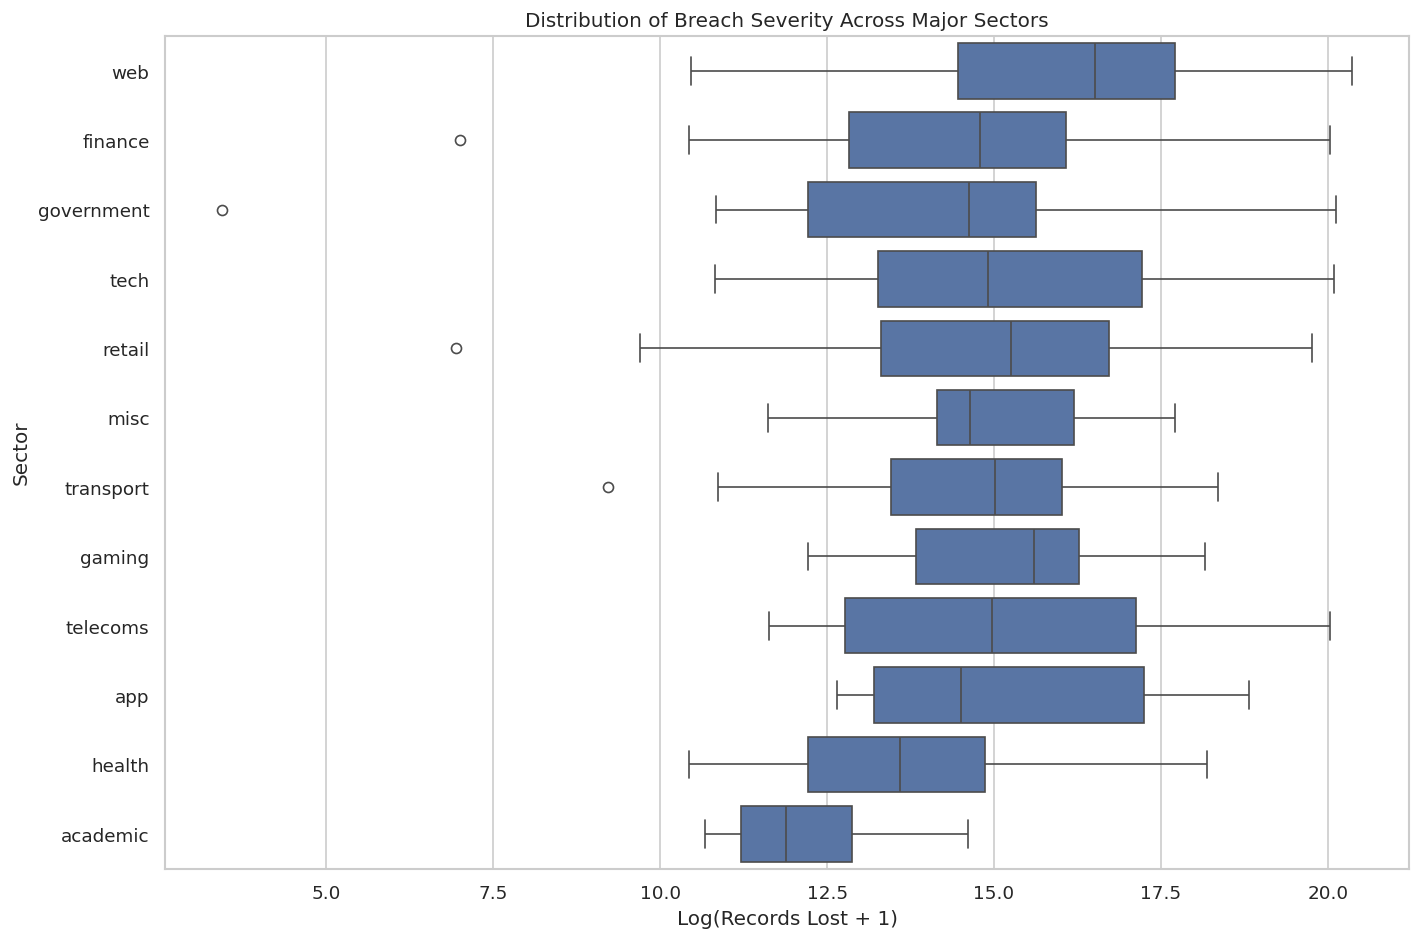

In [40]:
# Sector severity boxplot

# Select sectors with at least 5 observations
sector_counts = (
    analysis_df["sector"]
    .value_counts()
)

major_sectors = sector_counts[
    sector_counts >= 5
].index

sector_box_df = analysis_df[
    analysis_df["sector"].isin(major_sectors)
].copy()

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=sector_box_df,
    x="log_records_lost",
    y="sector"
)

plt.title(
    "Distribution of Breach Severity Across Major Sectors"
)

plt.xlabel("Log(Records Lost + 1)")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

In [41]:
# Breach method frequency

method_frequency = (
    analysis_df["method"]
    .value_counts()
    .reset_index()
)

method_frequency.columns = [
    "method",
    "breach_count"
]

method_frequency["percentage"] = (
    method_frequency["breach_count"]
    / len(analysis_df)
    * 100
)

display(method_frequency)

,method,breach_count,percentage
0,hacked,274,65.707
1,poor security,53,12.710
2,lost device,48,11.511
3,oops!,22,5.276
4,inside job,20,4.796


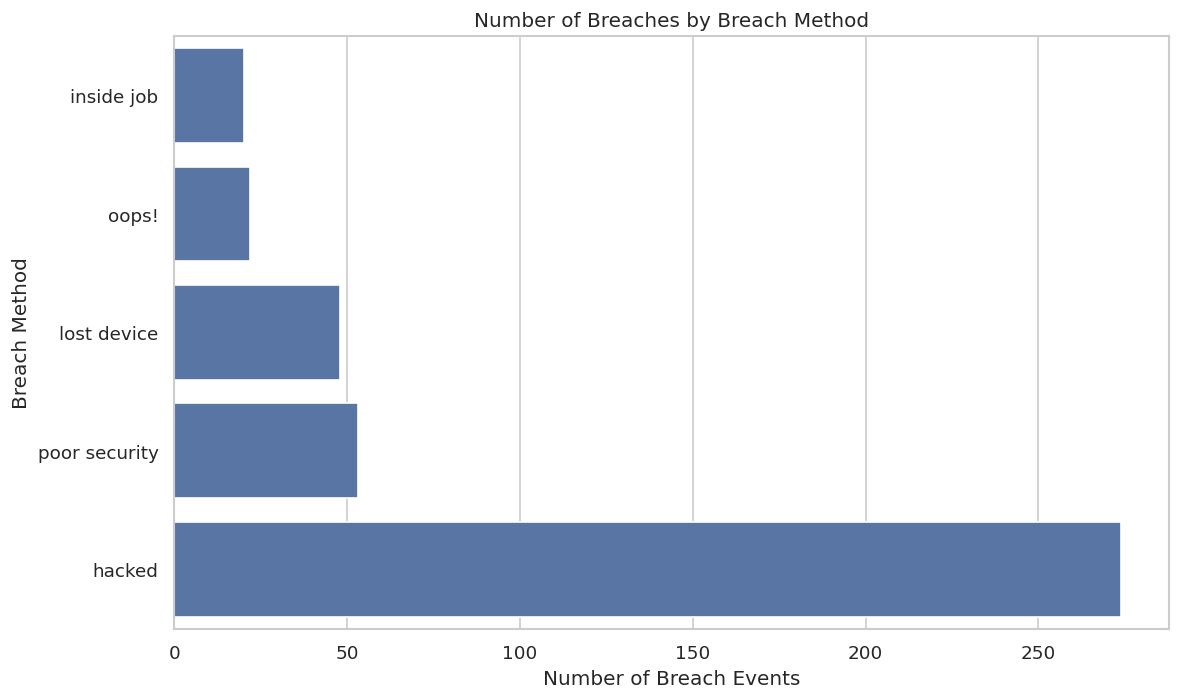

In [43]:
# Breach method plot

method_plot = (
    method_frequency
    .sort_values("breach_count", ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=method_plot,
    x="breach_count",
    y="method"
)

plt.title("Number of Breaches by Breach Method")
plt.xlabel("Number of Breach Events")
plt.ylabel("Breach Method")
plt.tight_layout()
plt.show()

In [44]:
# Method severity

method_summary = (
    analysis_df
    .groupby("method")
    .agg(
        breach_count=("records_lost", "count"),
        total_records_lost=("records_lost", "sum"),
        mean_records_lost=("records_lost", "mean"),
        median_records_lost=("records_lost", "median"),
        q1_records_lost=("records_lost", lambda x: x.quantile(0.25)),
        q3_records_lost=("records_lost", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

method_summary["percentage"] = (
    method_summary["breach_count"]
    / len(analysis_df)
    * 100
)

display(method_summary)

,method,breach_count,total_records_lost,mean_records_lost,median_records_lost,q1_records_lost,q3_records_lost,percentage
0,hacked,274,"9,273,769,852.000","33,845,875.372","4,000,000.000","500,000.000","22,000,000.000",65.707
1,inside job,20,"360,319,505.000","18,015,975.250","1,900,000.000","359,000.000","8,534,351.250",4.796
2,lost device,48,"215,319,713.000","4,485,827.354","911,604.500","152,750.000","3,400,000.000",11.511
3,oops!,22,"436,854,658.000","19,857,029.909","2,400,000.000","512,500.000","5,797,599.000",5.276
4,poor security,53,"4,053,217,483.000","76,475,801.566","6,500,000.000","1,000,000.000","52,500,000.000",12.710


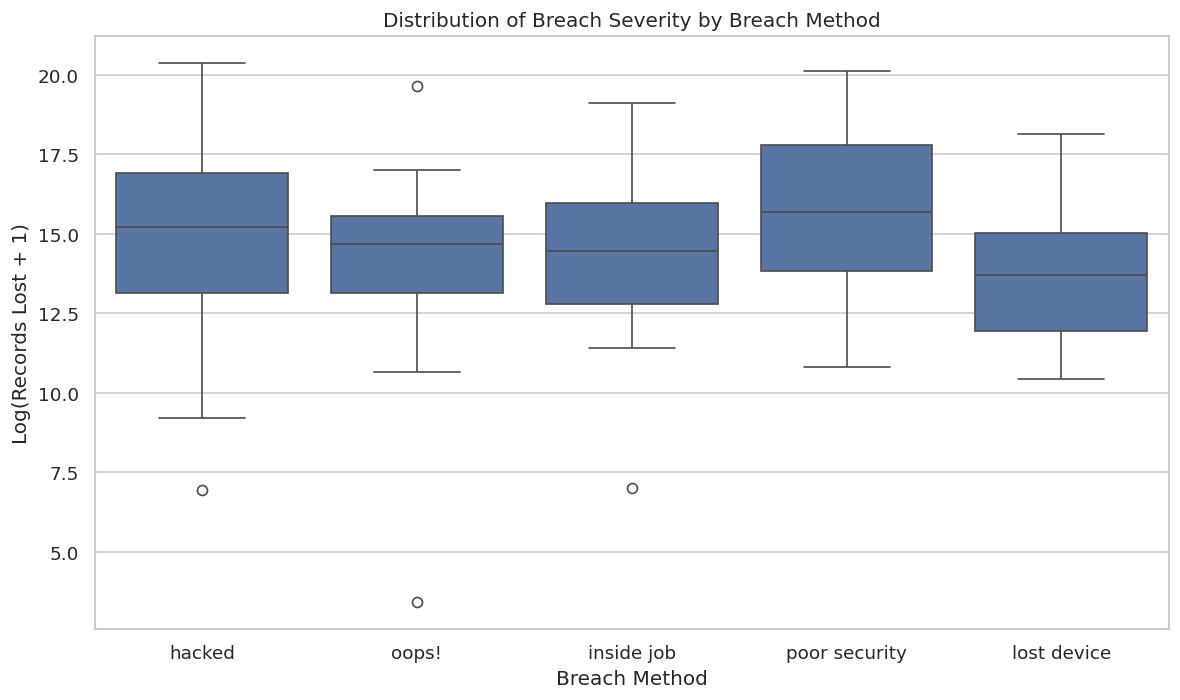

In [45]:
# Method severity boxplot

plt.figure(figsize=(10, 6))


sns.boxplot(
    data=analysis_df,
    x="method",
    y="log_records_lost"
)

plt.title("Distribution of Breach Severity by Breach Method")
plt.xlabel("Breach Method")
plt.ylabel("Log(Records Lost + 1)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# GDPR descriptive analysis

gdpr_summary = (
    analysis_df
    .groupby("gdpr_period")
    .agg(
        breach_count=("records_lost", "count"),
        total_records_lost=("records_lost", "sum"),
        mean_records_lost=("records_lost", "mean"),
        median_records_lost=("records_lost", "median"),
        q1_records_lost=("records_lost", lambda x: x.quantile(0.25)),
        q3_records_lost=("records_lost", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

gdpr_summary["percentage_of_breaches"] = (
    gdpr_summary["breach_count"]
    / len(analysis_df)
    * 100
)

display(gdpr_summary)

,gdpr_period,breach_count,total_records_lost,mean_records_lost,median_records_lost,q1_records_lost,q3_records_lost,percentage_of_breaches
0,Post-GDPR,160,"8,116,080,933.000","50,725,505.831","5,000,468.500","925,500.000","28,250,000.000",38.369
1,Pre-GDPR,257,"6,223,400,278.000","24,215,565.284","2,100,000.000","300,000.000","11,100,000.000",61.631


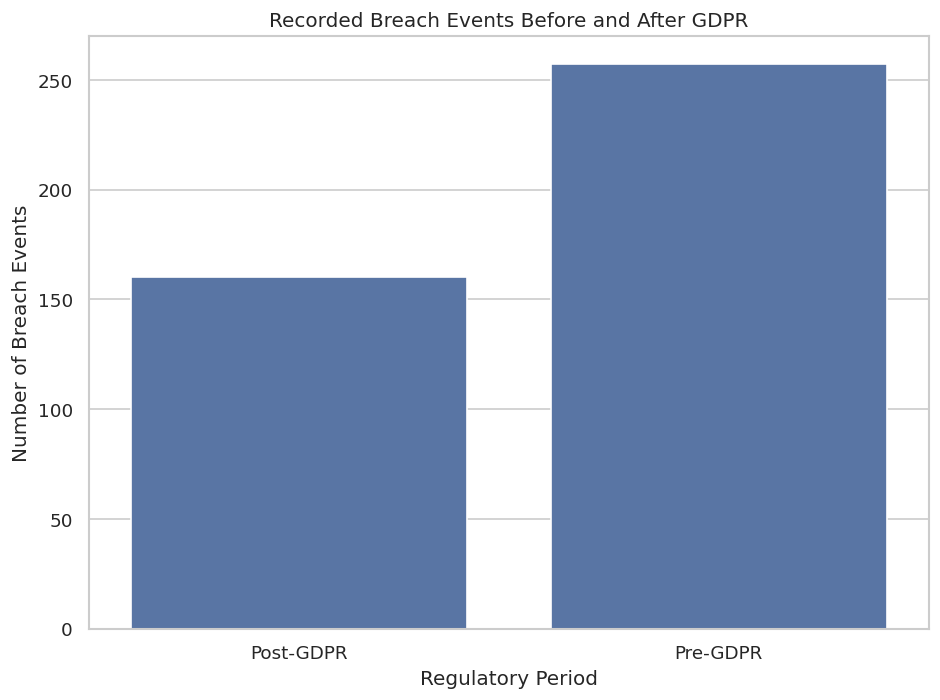

In [47]:
# GDPR frequency plot

plt.figure(figsize=(8, 6))

sns.barplot(
    data=gdpr_summary,
    x="gdpr_period",
    y="breach_count"
)

plt.title("Recorded Breach Events Before and After GDPR")
plt.xlabel("Regulatory Period")
plt.ylabel("Number of Breach Events")

plt.tight_layout()
plt.show()

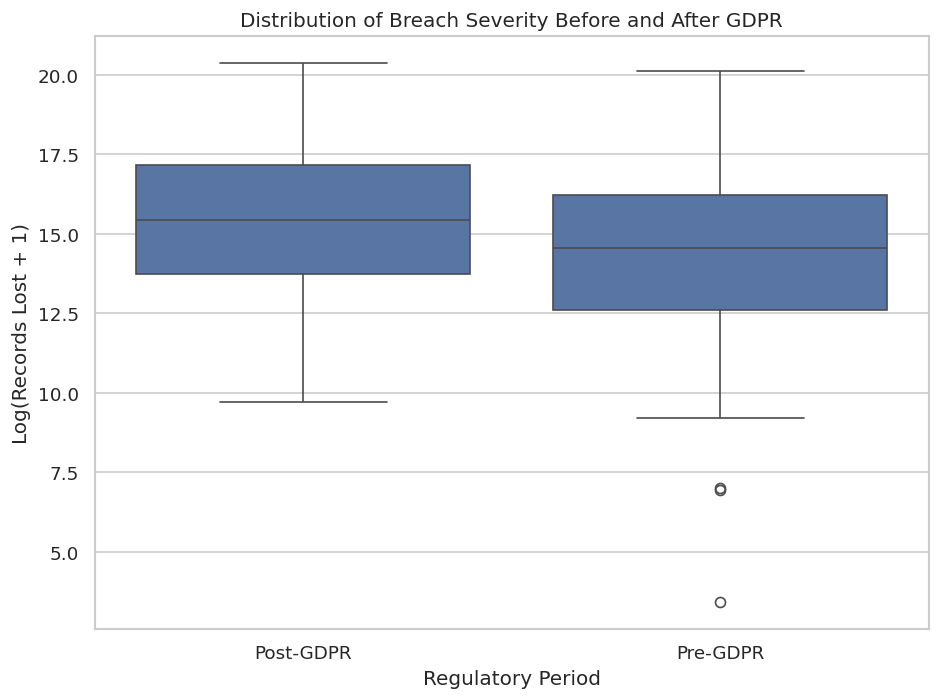

In [48]:
# GDPR severity plot

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_df,
    x="gdpr_period",
    y="log_records_lost"
)

plt.title(
    "Distribution of Breach Severity Before and After GDPR"
)

plt.xlabel("Regulatory Period")
plt.ylabel("Log(Records Lost + 1)")

plt.tight_layout()
plt.show()

In [50]:
# GDPR Mann–Whitney U test

pre_gdpr = analysis_df.loc[
    analysis_df["gdpr_period"] == "Pre-GDPR",
    "log_records_lost"
]

post_gdpr = analysis_df.loc[
    analysis_df["gdpr_period"] == "Post-GDPR",
    "log_records_lost"
]

u_gdpr, p_gdpr = mannwhitneyu(
    pre_gdpr,
    post_gdpr,
    alternative="two-sided"
)

print("GDPR Mann–Whitney U Test")
print(f"U statistic : {u_gdpr:,.3f}")
print(f"p-value     : {p_gdpr:.6f}")
print("--------------------------------")

if p_gdpr < 0.05:
    print("Conclusion: Statistically significant difference.")
else:
    print("Conclusion: No statistically significant difference.")

GDPR Mann–Whitney U Test
U statistic : 16,069.500
p-value     : 0.000176
--------------------------------
Conclusion: Statistically significant difference.


In [51]:
# Mann–Whitney effect size

n1 = len(pre_gdpr)
n2 = len(post_gdpr)

z_gdpr = stats.norm.ppf(
    p_gdpr / 2
)

# Use absolute z for effect size
z_gdpr = abs(z_gdpr)
r_gdpr = z_gdpr / np.sqrt(n1 + n2)
print(f"Effect size r = {r_gdpr:.3f}")

Effect size r = 0.184


In [52]:
def interpret_effect_size_r(r):
    if r < 0.10:
        return "Negligible"
    elif r < 0.30:
        return "Small"
    elif r < 0.50:
        return "Medium"
    else:
        return "Large"

print(
    "Interpretation:",
    interpret_effect_size_r(r_gdpr)
)

Interpretation: Small


In [53]:
# CCPA descriptive analysis

ccpa_summary = (
    analysis_df
    .groupby("ccpa_period")
    .agg(
        breach_count=("records_lost", "count"),
        total_records_lost=("records_lost", "sum"),
        mean_records_lost=("records_lost", "mean"),
        median_records_lost=("records_lost", "median"),
        q1_records_lost=("records_lost", lambda x: x.quantile(0.25)),
        q3_records_lost=("records_lost", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

ccpa_summary["percentage_of_breaches"] = (
    ccpa_summary["breach_count"]
    / len(analysis_df)
    * 100
)

display(ccpa_summary)

,ccpa_period,breach_count,total_records_lost,mean_records_lost,median_records_lost,q1_records_lost,q3_records_lost,percentage_of_breaches
0,Post-CCPA,74,"3,391,311,186.000","45,828,529.541","3,150,000.000","500,000.000","14,531,240.500",17.746
1,Pre-CCPA,343,"10,948,170,025.000","31,918,863.047","3,100,000.000","450,000.000","20,750,000.000",82.254


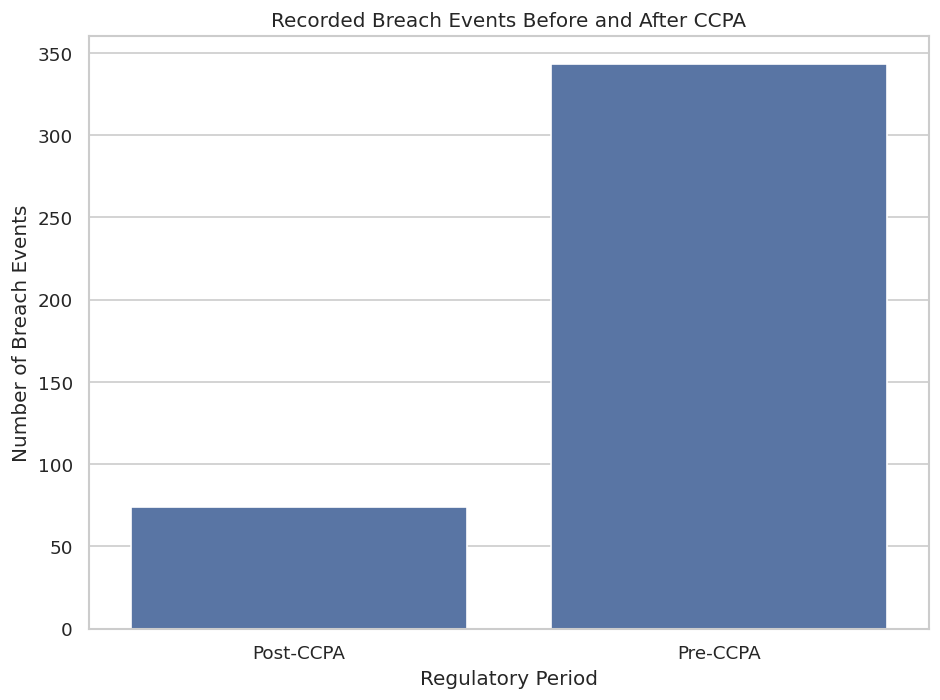

In [54]:
# CCPA frequency

plt.figure(figsize=(8, 6))

sns.barplot(
    data=ccpa_summary,
    x="ccpa_period",
    y="breach_count"
)

plt.title("Recorded Breach Events Before and After CCPA")
plt.xlabel("Regulatory Period")
plt.ylabel("Number of Breach Events")

plt.tight_layout()
plt.show()

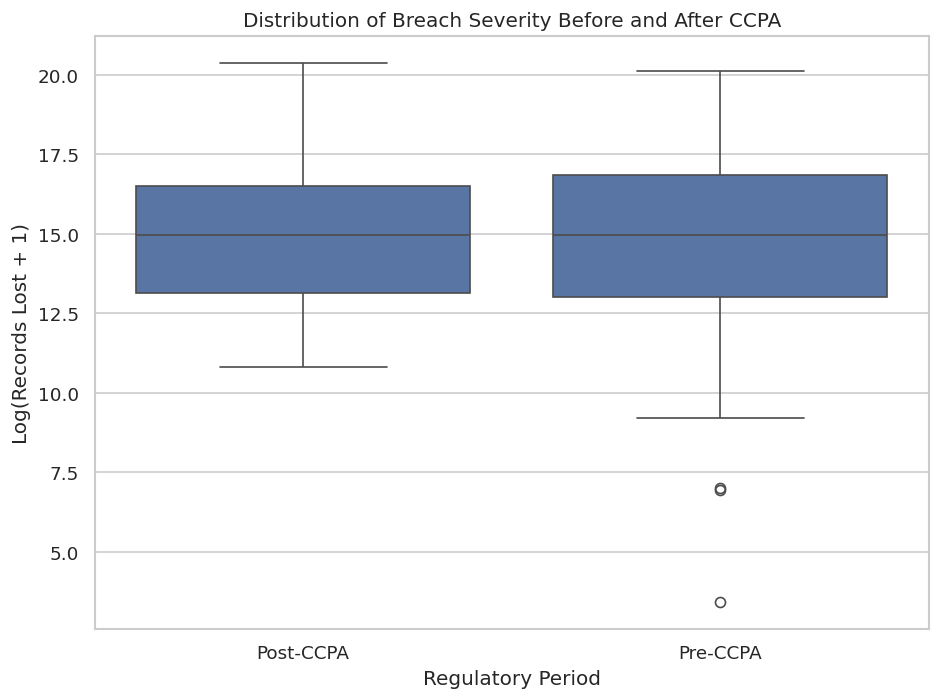

In [56]:
# CCPA severity

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_df,
    x="ccpa_period",
    y="log_records_lost"
)

plt.title(
    "Distribution of Breach Severity Before and After CCPA"
)

plt.xlabel("Regulatory Period")
plt.ylabel("Log(Records Lost + 1)")
plt.tight_layout()
plt.show()

In [57]:
# CCPA Mann–Whitney U

pre_ccpa = analysis_df.loc[
    analysis_df["ccpa_period"] == "Pre-CCPA",
    "log_records_lost"
]

post_ccpa = analysis_df.loc[
    analysis_df["ccpa_period"] == "Post-CCPA",
    "log_records_lost"
]

u_ccpa, p_ccpa = mannwhitneyu(
    pre_ccpa,
    post_ccpa,
    alternative="two-sided"
)

print("CCPA Mann–Whitney U Test")
print(f"U statistic : {u_ccpa:,.3f}")
print(f"p-value     : {p_ccpa:.6f}")
print("--------------------------------")

if p_ccpa < 0.05:
    print("Conclusion: Statistically significant difference.")
else:
    print("Conclusion: No statistically significant difference.")

CCPA Mann–Whitney U Test
U statistic : 12,645.000
p-value     : 0.961404
--------------------------------
Conclusion: No statistically significant difference.


In [58]:
# Chi Square Test

def chi_square_test(data, variable1, variable2):

    contingency_table = pd.crosstab(
        data[variable1],
        data[variable2]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    min_dim = min(
        contingency_table.shape
    ) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dim)
    ) if min_dim > 0 else np.nan

    return (
        contingency_table,
        chi2,
        p,
        dof,
        cramers_v
    )

In [60]:
# Chi Square - GDPR × method

gdpr_method_table, chi2_gm, p_gm, dof_gm, v_gm = (
    chi_square_test(
        analysis_df,
        "gdpr_period",
        "method"
    )
)

print("Contingency Table:")
display(gdpr_method_table)

print(f"Chi-square = {chi2_gm:.3f}")
print(f"Degrees of freedom = {dof_gm}")
print(f"p-value = {p_gm:.6f}")
print(f"Cramer's V = {v_gm:.3f}")

Contingency Table:


method,hacked,inside job,lost device,oops!,poor security
gdpr_period,,,,,
Post-GDPR,110,3,1,8,38
Pre-GDPR,164,17,47,14,15


Chi-square = 56.645
Degrees of freedom = 4
p-value = 0.000000
Cramer's V = 0.369


In [61]:
# Chi Square - GDPR × sector

gdpr_sector_table, chi2_gs, p_gs, dof_gs, v_gs = (
    chi_square_test(
        analysis_df,
        "gdpr_period",
        "sector"
    )
)

display(gdpr_sector_table)

print(f"Chi-square = {chi2_gs:.3f}")
print(f"Degrees of freedom = {dof_gs}")
print(f"p-value = {p_gs:.6f}")
print(f"Cramer's V = {v_gs:.3f}")

sector,academic,app,finance,gaming,government,"government, health","government, military",health,legal,military,"military, health",misc,"misc, health",ngo,retail,tech,"tech, app","tech, health","tech, retail","tech, web",telecoms,transport,web,"web, gaming","web, military","web, tech"
gdpr_period,,,,,,,,,,,,,,,,,,,,,,,,,,
Post-GDPR,1,12,12,8,11,0,0,6,1,0,0,3,1,1,22,17,0,1,0,0,9,14,41,0,0,0
Pre-GDPR,10,9,32,8,33,1,1,37,0,4,1,7,0,0,15,3,1,0,2,4,13,3,70,1,1,1


Chi-square = 81.208
Degrees of freedom = 25
p-value = 0.000000
Cramer's V = 0.441


In [64]:
# Chi Square - CCPA × method

ccpa_method_table, chi2_cm, p_cm, dof_cm, v_cm = (
    chi_square_test(
        analysis_df,
        "ccpa_period",
        "method"
    )
)

print("CCPA × Method")
display(ccpa_method_table)

print(f"Chi-square = {chi2_cm:.3f}")
print(f"df = {dof_cm}")
print(f"p-value = {p_cm:.6f}")
print(f"Cramer's V = {v_cm:.3f}")

CCPA × Method


method,hacked,inside job,lost device,oops!,poor security
ccpa_period,,,,,
Post-CCPA,55,2,1,4,12
Pre-CCPA,219,18,47,18,41


Chi-square = 10.779
df = 4
p-value = 0.029166
Cramer's V = 0.161


In [65]:
# # Chi Square - CCPA × sector

ccpa_sector_table, chi2_cs, p_cs, dof_cs, v_cs = (
    chi_square_test(
        analysis_df,
        "ccpa_period",
        "sector"
    )
)

print("\nCCPA × Sector")
display(ccpa_sector_table)

print(f"Chi-square = {chi2_cs:.3f}")
print(f"df = {dof_cs}")
print(f"p-value = {p_cs:.6f}")
print(f"Cramer's V = {v_cs:.3f}")


CCPA × Sector


sector,academic,app,finance,gaming,government,"government, health","government, military",health,legal,military,"military, health",misc,"misc, health",ngo,retail,tech,"tech, app","tech, health","tech, retail","tech, web",telecoms,transport,web,"web, gaming","web, military","web, tech"
ccpa_period,,,,,,,,,,,,,,,,,,,,,,,,,,
Post-CCPA,0,5,7,3,8,0,0,1,0,0,0,2,1,1,11,11,0,1,0,0,6,7,10,0,0,0
Pre-CCPA,11,16,37,13,36,1,1,42,1,4,1,8,0,0,26,9,1,0,2,4,16,10,101,1,1,1


Chi-square = 64.072
df = 25
p-value = 0.000028
Cramer's V = 0.392


In [66]:
# Kruskal–Wallis: severity by method

method_groups = [
    group["log_records_lost"].values
    for name, group
    in analysis_df.groupby("method")
]

h_method, p_method = kruskal(
    *method_groups
)

print("Kruskal–Wallis Test: Severity by Breach Method")
print(f"H statistic = {h_method:.3f}")
print(f"p-value     = {p_method:.6f}")
print("-----------------------------------------------")

if p_method < 0.05:
    print("Conclusion: Severity differs significantly across methods.")
else:
    print("Conclusion: No statistically significant difference detected.")

Kruskal–Wallis Test: Severity by Breach Method
H statistic = 22.508
p-value     = 0.000159
-----------------------------------------------
Conclusion: Severity differs significantly across methods.


In [67]:
# Kruskal–Wallis: severity by sector

sector_counts = analysis_df["sector"].value_counts()

eligible_sectors = sector_counts[
    sector_counts >= 5
].index

sector_test_df = analysis_df[
    analysis_df["sector"].isin(eligible_sectors)
].copy()

sector_groups = [
    group["log_records_lost"].values
    for name, group
    in sector_test_df.groupby("sector")
]

h_sector, p_sector = kruskal(
    *sector_groups
)

print("Kruskal–Wallis Test: Severity by Sector")
print(f"H statistic = {h_sector:.3f}")
print(f"p-value     = {p_sector:.6f}")

Kruskal–Wallis Test: Severity by Sector
H statistic = 60.494
p-value     = 0.000000


In [68]:
# Regression Dataset

reg_df = analysis_df.copy()

# Convert categorical variables to category
reg_df["sector"] = reg_df["sector"].astype("category")
reg_df["method"] = reg_df["method"].astype("category")
reg_df["gdpr_period"] = reg_df["gdpr_period"].astype("category")
reg_df["ccpa_period"] = reg_df["ccpa_period"].astype("category")

print(reg_df.shape)

(417, 12)


In [69]:
# OLS regression

model_ols = smf.ols(
    formula="""
    log_records_lost ~ year
    + C(gdpr_period)
    + C(ccpa_period)
    + C(sector)
    + C(method)
    """,
    data=reg_df
).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:       log_records_lost   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     2.889
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           7.77e-07
Time:                        08:25:34   Log-Likelihood:                -930.21
No. Observations:                 417   AIC:                             1926.
Df Residuals:                     384   BIC:                             2060.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [70]:
# Regression results table

regression_results = pd.DataFrame({
    "Coefficient": model_ols.params,
    "Std_Error": model_ols.bse,
    "t_value": model_ols.tvalues,
    "p_value": model_ols.pvalues,
    "CI_Lower": model_ols.conf_int()[0],
    "CI_Upper": model_ols.conf_int()[1]
})

display(regression_results)

,Coefficient,Std_Error,t_value,p_value,CI_Lower,CI_Upper
Intercept,13.925,111.990,0.124,0.901,-206.265,234.115
C(gdpr_period)[T.Pre-GDPR],-0.946,0.429,-2.205,0.028,-1.790,-0.102
C(ccpa_period)[T.Pre-CCPA],0.600,0.416,1.443,0.150,-0.217,1.417
C(sector)[T.app],2.413,0.903,2.673,0.008,0.638,4.188
C(sector)[T.finance],2.385,0.803,2.972,0.003,0.807,3.963
C(sector)[T.gaming],2.608,0.937,2.783,0.006,0.766,4.451
C(sector)[T.government],1.800,0.799,2.252,0.025,0.229,3.371
"C(sector)[T.government, health]",1.289,2.456,0.525,0.600,-3.539,6.117
"C(sector)[T.government, military]",5.210,2.474,2.106,0.036,0.347,10.074
C(sector)[T.health],1.391,0.810,1.717,0.087,-0.201,2.983


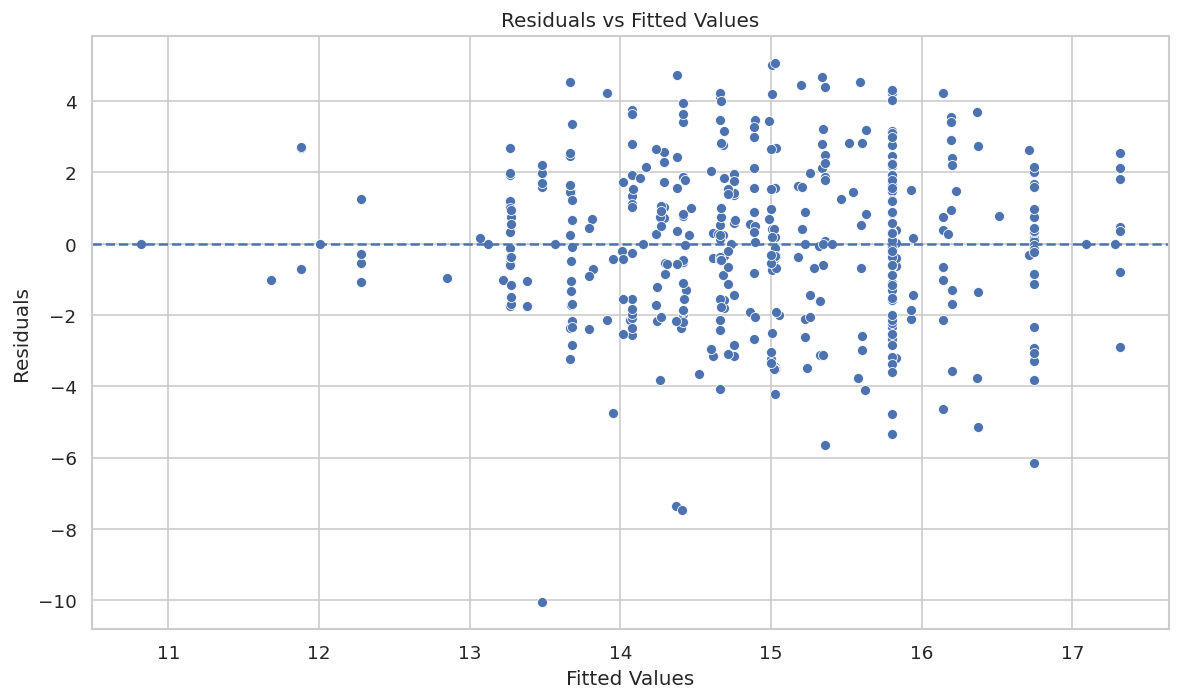

In [71]:
# Check model diagnostics

residuals = model_ols.resid
fitted = model_ols.fittedvalues

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=fitted,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [72]:
# Define ML target correctly

ml_df = analysis_df.copy()

features = [
    "year",
    "sector",
    "method",
    "gdpr_post",
    "ccpa_post"
]

X = ml_df[features].copy()

y_severity = ml_df["records_lost"].copy()

print("Predictor variables:")
print(features)

Predictor variables:
['year', 'sector', 'method', 'gdpr_post', 'ccpa_post']


In [73]:
# Train/test split

X_train, X_test, severity_train, severity_test = train_test_split(
    X,
    y_severity,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

Training observations: 333
Testing observations : 84


In [74]:
# Calculate high-severity threshold from training data

severity_threshold = severity_train.quantile(0.75)

print(
    "Training-data 75th percentile:",
    f"{severity_threshold:,.0f}"
)

y_train = (
    severity_train >= severity_threshold
).astype(int)

y_test = (
    severity_test >= severity_threshold
).astype(int)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training-data 75th percentile: 20,000,000

Training class distribution:
records_lost
0    249
1     84
Name: count, dtype: int64

Testing class distribution:
records_lost
0    64
1    20
Name: count, dtype: int64


In [75]:
# Preprocessing Pipeline

categorical_features = [
    "sector",
    "method"
]

numeric_features = [
    "year",
    "gdpr_post",
    "ccpa_post"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [76]:
# Logistic Regression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_pred = logistic_pipeline.predict(
    X_test
)

logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [77]:
# Decision Tree

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        )
    )
])

tree_pipeline.fit(
    X_train,
    y_train
)

tree_pred = tree_pipeline.predict(
    X_test
)

tree_prob = tree_pipeline.predict_proba(
    X_test
)[:, 1]

In [78]:
# Random Forest

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

rf_pred = rf_pipeline.predict(
    X_test
)

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

In [79]:
# Gradient Boosting

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

gb_pipeline.fit(
    X_train,
    y_train
)

gb_pred = gb_pipeline.predict(
    X_test
)

gb_prob = gb_pipeline.predict_proba(
    X_test
)[:, 1]

In [80]:
# XGBoost

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_pred = xgb_pipeline.predict(
    X_test
)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

In [81]:
# Model Evaluation Function

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_probability
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_probability
        )
    }

In [82]:
# Compare all models

model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

model_results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred,
        tree_prob
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

model_results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_prob
    )
)

model_results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)

model_results_df = pd.DataFrame(
    model_results
)

display(
    model_results_df.sort_values(
        "F1",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Random Forest,0.690,0.333,0.300,0.316,0.691,0.476
1,Decision Tree,0.750,0.444,0.200,0.276,0.657,0.358
4,XGBoost,0.702,0.308,0.200,0.242,0.617,0.352
0,Logistic Regression,0.762,0.500,0.100,0.167,0.722,0.470
3,Gradient Boosting,0.702,0.222,0.100,0.138,0.642,0.340


In [83]:
# Classification Reports

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

for model_name, predictions_model in predictions.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions_model,
            target_names=[
                "Normal Severity",
                "High Severity"
            ],
            zero_division=0
        )
    )


Logistic Regression
                 precision    recall  f1-score   support

Normal Severity       0.78      0.97      0.86        64
  High Severity       0.50      0.10      0.17        20

       accuracy                           0.76        84
      macro avg       0.64      0.53      0.51        84
   weighted avg       0.71      0.76      0.70        84


Decision Tree
                 precision    recall  f1-score   support

Normal Severity       0.79      0.92      0.85        64
  High Severity       0.44      0.20      0.28        20

       accuracy                           0.75        84
      macro avg       0.62      0.56      0.56        84
   weighted avg       0.71      0.75      0.71        84


Random Forest
                 precision    recall  f1-score   support

Normal Severity       0.79      0.81      0.80        64
  High Severity       0.33      0.30      0.32        20

       accuracy                           0.69        84
      macro avg       0.56   

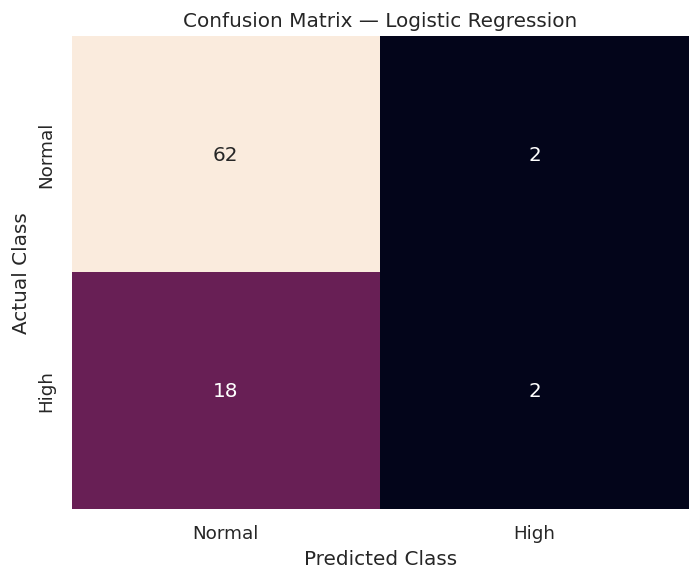

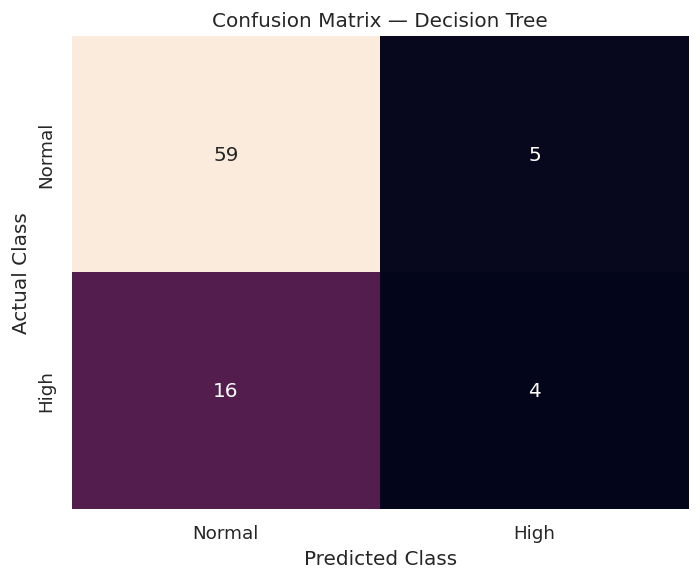

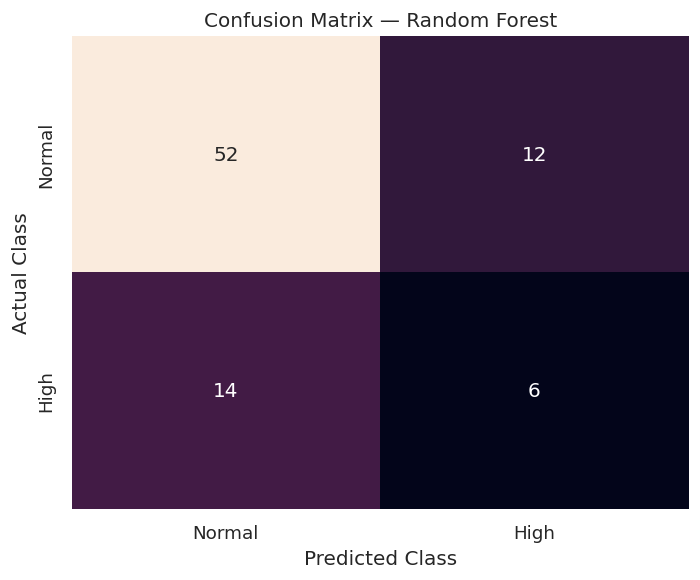

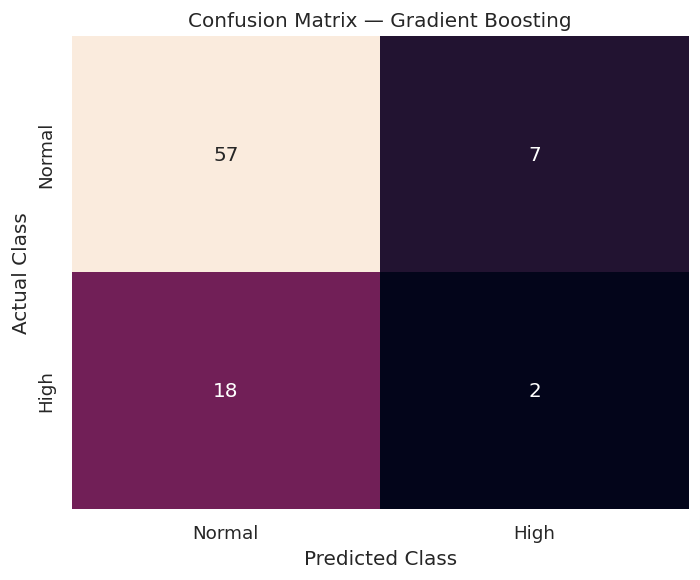

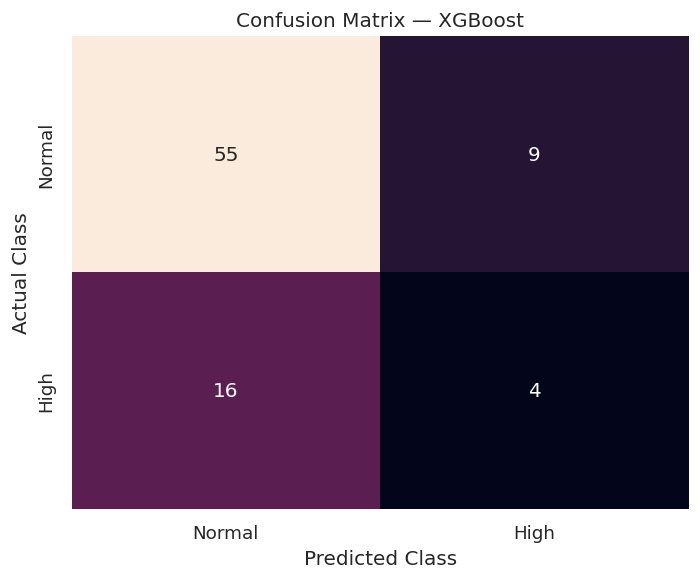

In [84]:
# Confusion Matrices

confusion_matrices = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

for model_name, pred in confusion_matrices.items():

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=[
            "Normal",
            "High"
        ],
        yticklabels=[
            "Normal",
            "High"
        ]
    )

    plt.title(
        f"Confusion Matrix — {model_name}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

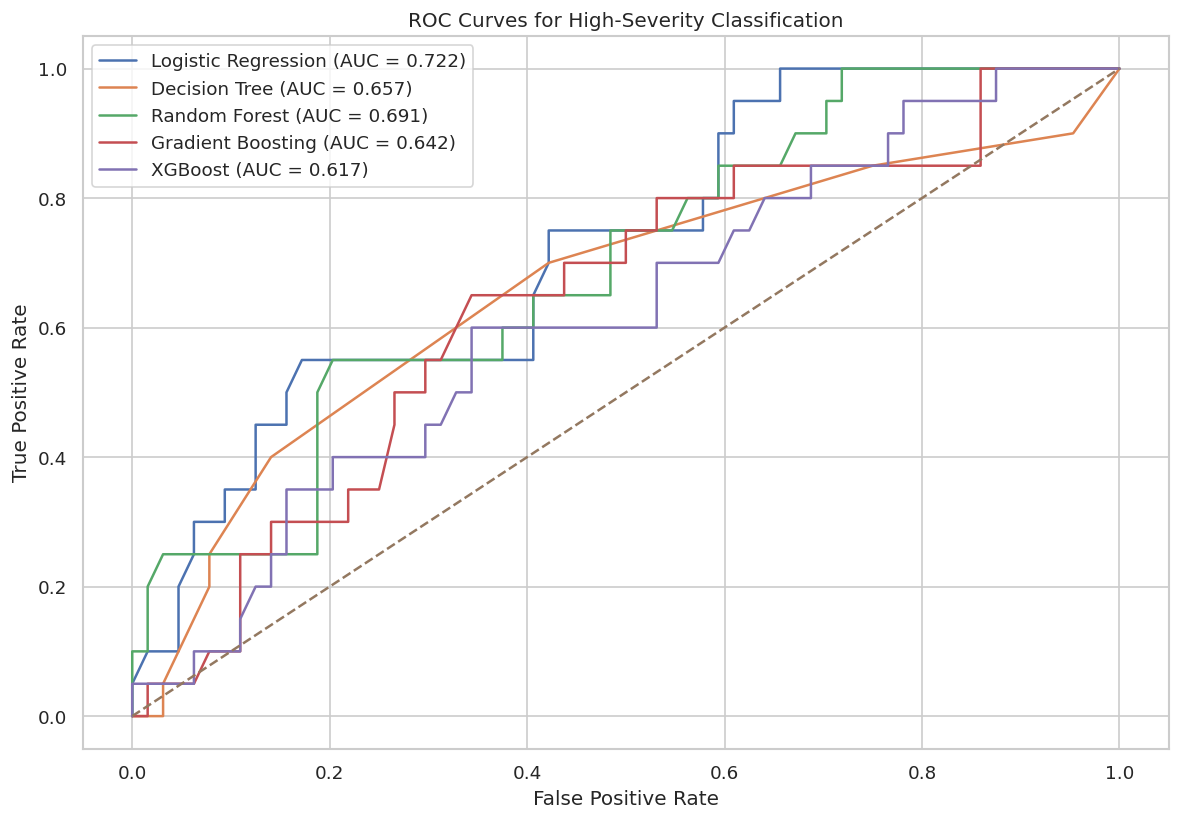

In [85]:
# ROC Curves

probabilities = {
    "Logistic Regression": logistic_prob,
    "Decision Tree": tree_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob,
    "XGBoost": xgb_prob
}

plt.figure(figsize=(10, 7))

for model_name, probability in probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves for High-Severity Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

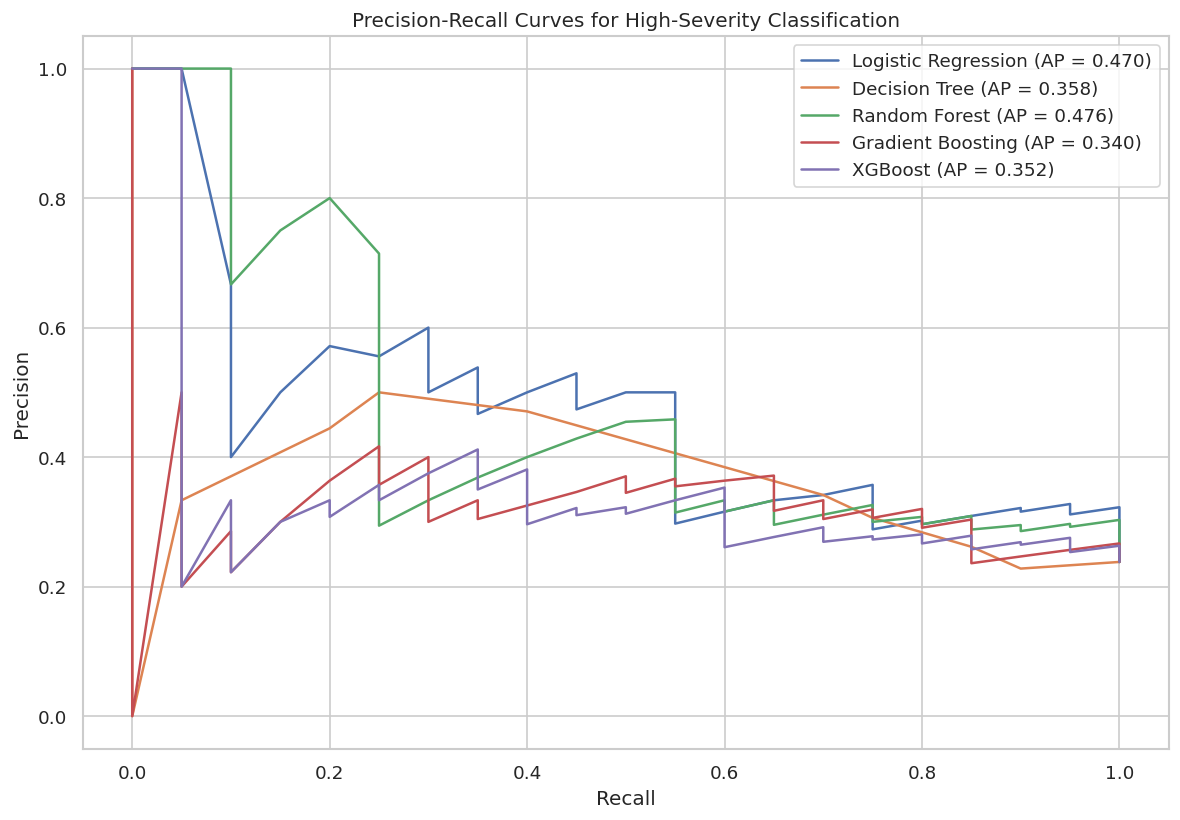

In [86]:
# Precision-Recall Curves

plt.figure(figsize=(10, 7))

for model_name, probability in probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probability
    )

    ap = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {ap:.3f})"
    )

plt.title(
    "Precision-Recall Curves for High-Severity Classification"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
# Random Forest Feature Importance

# Extract the preprocessing component
rf_preprocessor = (
    rf_pipeline
    .named_steps["preprocessor"]
)

# Get names of transformed/encoded variables
rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Extract trained Random Forest model
rf_model = (
    rf_pipeline
    .named_steps["model"]
)

# Create feature importance table
rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort from most to least important
rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 20 Random Forest features:")
display(
    rf_importance.head(20)
)


Top 20 Random Forest features:


,Feature,Importance
0,numeric__year,0.382
1,categorical__sector_web,0.091
2,categorical__sector_health,0.049
3,numeric__ccpa_post,0.039
4,numeric__gdpr_post,0.036
5,categorical__method_hacked,0.033
6,categorical__sector_retail,0.030
7,categorical__sector_telecoms,0.030
8,categorical__sector_finance,0.029
9,categorical__method_poor security,0.028


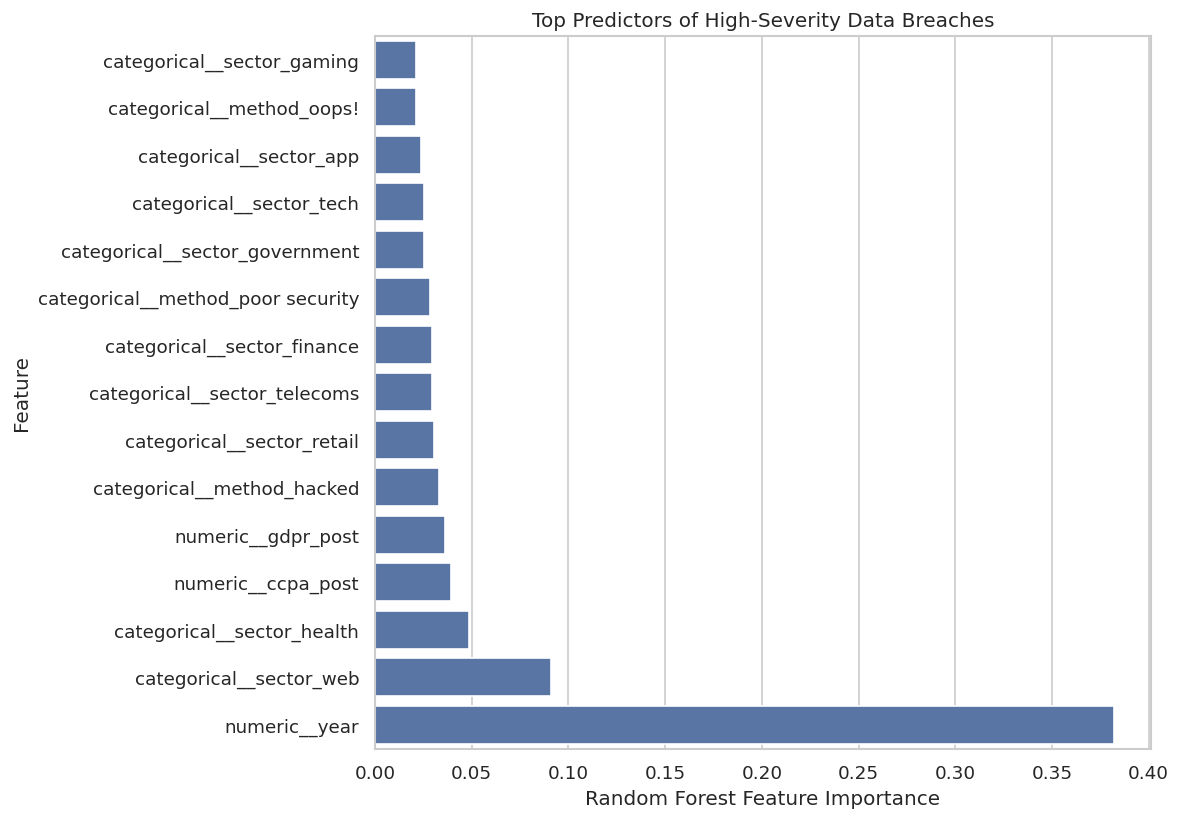

In [90]:
# Random Forest Feature Importance Plot

top_rf_features = (
    rf_importance
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictors of High-Severity Data Breaches"
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [93]:
# SHAP Analysis


# Transform test data using the same preprocessing
X_test_rf_transformed = (
    rf_pipeline
    .named_steps["preprocessor"]
    .transform(X_test)
)

# Extract trained Random Forest
rf_model = (
    rf_pipeline
    .named_steps["model"]
)

# Create SHAP TreeExplainer
rf_explainer = shap.TreeExplainer(
    rf_model
)

# Calculate SHAP values
rf_shap_values = rf_explainer(
    X_test_rf_transformed
)

<Figure size 1200x720 with 0 Axes>

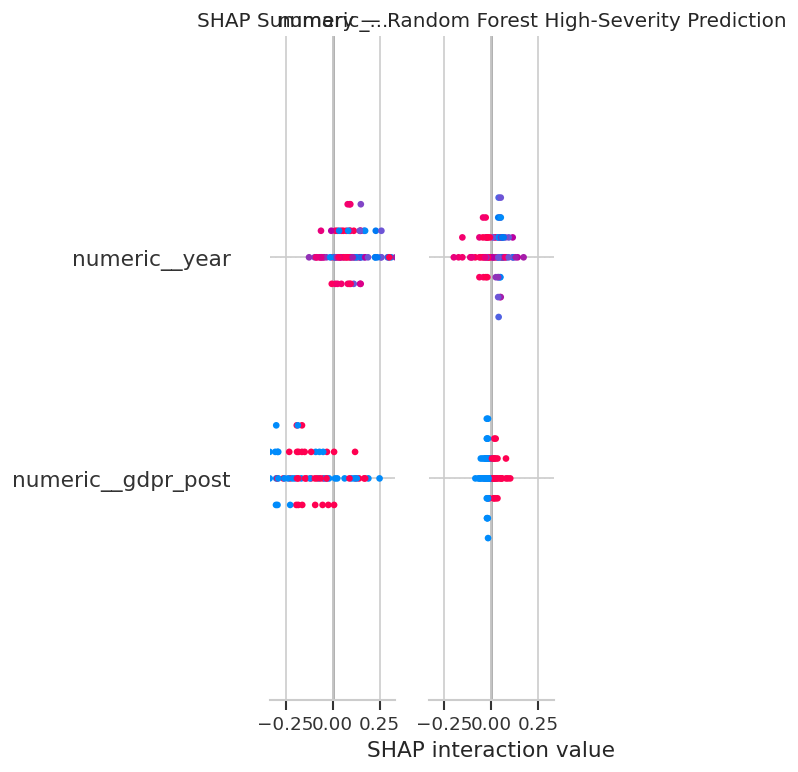

In [94]:
# SHAP Summary Plot

plt.figure()
shap.summary_plot(
    rf_shap_values,
    X_test_rf_transformed,
    feature_names=rf_feature_names,
    show=False
)

plt.title(
    "SHAP Summary — Random Forest High-Severity Prediction"
)

plt.tight_layout()
plt.show()

In [96]:
OUTPUT_DIR = "./"
# Export Cleaned Dataset

analysis_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cleaned_breach_analysis_dataset.csv"
    ),
    index=False
)

In [100]:
# Save statistical tables to Excel

with pd.ExcelWriter(
    "Statistical_Results.xlsx",
    engine="openpyxl"
) as writer:

    cleaning_summary.to_excel(
        writer,
        sheet_name="Cleaning Summary",
        index=False
    )

    severity_descriptive.to_excel(
        writer,
        sheet_name="Severity Descriptive",
        index=False
    )

    annual_breaches.to_excel(
        writer,
        sheet_name="Annual Breaches",
        index=False
    )

    annual_severity.to_excel(
        writer,
        sheet_name="Annual Severity",
        index=False
    )

    sector_frequency.to_excel(
        writer,
        sheet_name="Sector Frequency",
        index=False
    )

    sector_summary.to_excel(
        writer,
        sheet_name="Sector Severity",
        index=False
    )

    method_frequency.to_excel(
        writer,
        sheet_name="Method Frequency",
        index=False
    )

    method_summary.to_excel(
        writer,
        sheet_name="Method Severity",
        index=False
    )

    gdpr_summary.to_excel(
        writer,
        sheet_name="GDPR Summary",
        index=False
    )

    ccpa_summary.to_excel(
        writer,
        sheet_name="CCPA Summary",
        index=False
    )

    regression_results.to_excel(
        writer,
        sheet_name="Regression",
        index=True
    )

    model_results_df.to_excel(
        writer,
        sheet_name="ML Results",
        index=False
    )

    rf_importance.to_excel(
        writer,
        sheet_name="RF Importance",
        index=False
    )

In [101]:
# Export important contingency tables

with pd.ExcelWriter(
    "Contingency_Tables.xlsx",
    engine="openpyxl"
) as writer:

    gdpr_method_table.to_excel(
        writer,
        sheet_name="GDPR_Method"
    )

    gdpr_sector_table.to_excel(
        writer,
        sheet_name="GDPR_Sector"
    )

    ccpa_method_table.to_excel(
        writer,
        sheet_name="CCPA_Method"
    )

    ccpa_sector_table.to_excel(
        writer,
        sheet_name="CCPA_Sector"
    )